# Gas-calibrated feedback and its cosmological reach: full analysis walkthrough

**Companion notebook to the Paper-3A data release.** It reproduces the
headline numbers and figures from the frozen data products in the release
bundle, and records the design decisions in the order they were made.

**How to run** — unpack the data-product bundle (`paper3a_products_v1`,
~113 MB), then:

```bash
export PAPER3A_PRODUCTS=/path/to/paper3a_products_v1
jupyter nbconvert --to notebook --execute paperA_walkthrough.ipynb
```

Requirements: `python >= 3.10`, `numpy`, `matplotlib`. Nothing here
imports the analysis package — the notebook is intentionally
self-contained so the numbers can be checked without installing anything
else.

**The one-sentence result.** Calibrating TNG-family feedback against kSZ
and X-ray gas fractions produces a posterior that is individually
reasonable probe-by-probe and **jointly rejected** — no corner of the
30-parameter feedback space fits all four probes at once — and that
calibrated band, used as a weak-lensing prior, absorbs ~93–99% of a
DES-Y6-style $S_8$ offset while beating scale cuts on precision.

In [1]:
import hashlib, json, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(os.environ.get("PAPER3A_PRODUCTS", "./paper3a_products_v1"))
MAN = json.loads((ROOT / "MANIFEST.json").read_text())
print(f"bundle {MAN['version']}: {len(MAN['files'])} files")

def sha256(p):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for c in iter(lambda: f.read(1 << 20), b""):
            h.update(c)
    return h.hexdigest()

def load(rel):
    p = ROOT / rel
    assert sha256(p) == MAN["files"][rel]["sha256"], f"CHECKSUM FAILED: {rel}"
    return np.load(p, allow_pickle=False) if p.suffix == ".npz" \
        else json.loads(p.read_text())

bundle paper3a_products_v1: 49 files


## 1. Integrity

Two independent checks. First, every bundled file against the manifest
checksum (the `load()` helper above does this on every read, so any
corruption surfaces at point of use rather than in a preamble you might
skip). Second, the **frozen source hashes**: the sha256 of every raw
observational input the analysis was frozen against, recorded at data
assembly and re-verified when the bundle was sealed.

Those raw inputs are third-party data releases (eROSITA eRASS1, the
DESI×ACT kSZ profile sets, the shear×tSZ vectors) and are not
redistributed here — but the hashes let you confirm you have the same
bytes we did before comparing any number.

In [2]:
frozen = MAN["wp1_frozen_source_hashes"]
n = sum(len(v) for v in frozen.values())
print(f"WP1 frozen sources: {len(frozen)} datasets, {n} files pinned")
for src, files in frozen.items():
    print(f"  {src:38s} {len(files):3d} files")

bad = [r for r in MAN["files"] if sha256(ROOT / r) != MAN["files"][r]["sha256"]]
print("\nbundle checksum:", "ALL OK" if not bad else f"FAILED: {bad}")

WP1 frozen sources: 6 datasets, 148 files pinned
  egas_erass1_bulbul                       4 files
  kappa_y_pandey_2506.07432                1 files
  ksz_hadzhiyska_2407.07152               44 files
  ksz_hadzhiyska_2604.19745               47 files
  ksz_qu_2604.19744                       28 files
  ksz_ried_guachalla_2503.19870           24 files



bundle checksum: ALL OK


## 2. The chain, and why it is ordered this way

1. **WP-A1 — freeze the data first.** Observational vectors are frozen
   with sha256 records before any model is run, and loaded only through
   hash-guarded loaders. Several sources publish multiple pipeline
   variants; the choice of fiducial is recorded per source rather than
   inferred at use time.
2. **WP-A2/A4 — build and validate the forward operator**, including the
   cylinder-to-sphere aperture correction, then the **gas emulator**: per
   snapshot, PCA + ARD Matérn-5/2 GPs over the 30-parameter CAMELS-TNG
   design.
3. **WP-A5 — pass a recovery battery before touching data.** The
   pre-registered gate is simulation-based: inject known parameters,
   confirm they are recovered with correct coverage. No data fit was run
   before its battery passed.
4. **WP-A6 — propagate** the posterior to weak-lensing statistics through
   a second emulator trained on the SB35 Sobol design.
5. **WP-A7 — translate** into survey-facing safe-scale tables and the
   $S_8$ exercise.

The ordering is the point: every gate is pre-registered, and where a
criterion later proved flawed it was amended **on the record** rather
than quietly.

In [3]:
rec = {k: load(f"wp5_chains/a5_recovery{s}.json")
       for k, s in [("f_gas", ""), ("kSZ-only", "_kszonly"),
                    ("A joint", "_joint"), ("A+B joint", "_jointab")]}
print("Recovery batteries (the gate that had to pass before any data fit):")
for k, v in rec.items():
    p = v.get("PASS", v.get("recovery_gate", {}).get("PASS"))
    print(f"  {k:10s} PASS={p}")

Recovery batteries (the gate that had to pass before any data fit):
  f_gas      PASS=True
  kSZ-only   PASS=True
  A joint    PASS=True
  A+B joint  PASS=True


## 3. The calibration, and the first sign of trouble

Fitting the gas fractions alone gives a well-behaved posterior. Fitting
the kSZ profiles alone also gives an acceptable $\chi^2$ — but its
posterior **piles against the prior edge**, which is a pre-registered
tripwire, not a detail: it means the data want a solution the model
family cannot reach.

Taken together the two probes are no longer reconcilable. This is the
structure that repeats at every level of the analysis: *individually
marginal, jointly rejected.*

In [4]:
ks = load("wp5_chains/a5_fit_kszonly_summary.json")
jt = load("wp5_chains/a5_fit_joint_summary.json")

def chi2_line(tag, s):
    b = s["map"]["chi2_per_block"]          # KeyError if the schema moves
    assert b, f"{tag}: empty chi2_per_block"
    tot = sum(v["chi2"] for v in b.values())
    dof = sum(v["n"] for v in b.values())
    blocks = "  ".join(f"{k} {v['chi2']:.1f}/{v['n']}" for k, v in b.items())
    print(f"{tag:10s} total {tot:6.1f}/{dof:<3d}  p_pp = "
          f"{s['posterior_predictive_p_ksz']:.3f}   {blocks}")

chi2_line("kSZ only", ks)
chi2_line("A joint", jt)
print("\nIndividually marginal (p = 0.04), jointly rejected (p = 0.000).")

kSZ only   total   10.8/9    p_pp = 0.040   ksz 10.8/9
A joint    total   55.3/14   p_pp = 0.000   ksz 34.5/9  fgas 20.8/5

Individually marginal (p = 0.04), jointly rejected (p = 0.000).


## 4. The four-probe joint fit — the headline

Adding the third and fourth probes (the $\kappa$-peak $\times$ $y$ stack
from the companion analysis, plus its positional-scatter nuisance) closes
the argument. The joint posterior:

- lands at $\Delta \ln M_{\rm gas} \approx -0.35$, past every single-probe
  preference,
- **saturates** its positional-scatter prior at the maximum,
- pins seven wind/black-hole-sector parameters against prior edges,
- and is **still rejected in every block at the MAP**, with posterior
  predictive $p = 0.000$.

The compatible corner does not exist. That is the paper's result, and it
is why the calibrated band below must be read as *"the range TNG feedback
can be calibrated to"* rather than as a measurement of the real Universe.

In [5]:
J = load("wp5_chains/joint_ab_summary.json")
m = J["map"]
print("Joint A+B fit")
print(f"  R-hat max         {J['chain']['cross_chain_rhat_max']:.5f}"
      f"   ({J['chain']['n_samples']:,} samples)")
print(f"  posterior pred p  {J['posterior_predictive_p_b']}")
print("  chi2 per block at the MAP:")
for k, v in m["chi2_per_block"].items():
    print(f"     {k:18s} {v['chi2']:7.1f} / {v['n']}")
c = J["coords_posterior"]
print(f"\n  dln M_gas = {c['dln_mgas']['p50']:+.3f} "
      f"[{c['dln_mgas']['p16']:+.3f}, {c['dln_mgas']['p84']:+.3f}]")
sp = J["sigma_pos_posterior_arcmin"]
print(f"  sigma_pos = {sp['p50']:.2f}' [{sp['p16']:.2f}, {sp['p84']:.2f}] "
      f"-- SATURATED against its prior maximum")
print(f"\n  parameters piled at a prior edge: "
      f"{len(J['boundary_tripwire_fired'])}")
for k in J["boundary_tripwire_fired"]:
    print(f"     {k}")

Joint A+B fit
  R-hat max         1.00106   (750,592 samples)
  posterior pred p  0.0
  chi2 per block at the MAP:
     fgas                  19.8 / 5
     ksz                   37.6 / 9
     b_kappa_y_peaks      106.6 / 4

  dln M_gas = -0.353 [-0.376, -0.327]
  sigma_pos = 3.56' [3.50, 3.59] -- SATURATED against its prior maximum

  parameters piled at a prior edge: 7
     VariableWindVelFactor
     RadioFeedbackReiorientationFactor
     FactorForSofterEQS
     WindFreeTravelDensFac
     SeedBlackHoleMass
     BlackHoleRadiativeEfficiency
     UVBH0Deltaz


## 5. Propagation — and an honest word about the emulator

The posterior is propagated to weak-lensing observables through a second
emulator (`statsemu_gp.npz`) trained on the SB35 Sobol design, carrying 23
targets.

**They are not equally trustworthy, and the bundle says so.** Before using
any target, read `statsemu_gp_validation.json`: it records how many
training runs were scored and the out-of-sample residual in units of the
measurement error. One target (`wst`) is trained on 40 runs where the rest
have 253, and its prediction error *exceeds* the survey statistical error
it would be compared against — so no safe-scale statement can be derived
from it in either direction. The WP-A7 tables gate on this explicitly.

Note also what the emulator does **not** carry: there are no $y$-field
morphology or environment statistics in it. The $y$-carrying targets are
`cl_kappa_y`, `cl_yy`, `cl_yt`, `peak_y` and `scaling_Y`, and no others.

In [6]:
V = load("wp6_propagation/statsemu_gp_validation.json")
rows = [(t, d.get("n_scored"), d.get("err_rel_med")) for t, d in V.items()]
rows.sort(key=lambda r: (r[1] or 0))
print(f"{'target':18s} {'n_train':>7s} {'out-of-sample err / meas.err':>28s}")
for t, n, e in rows:
    flag = "   <-- sparse training" if (n or 0) < 100 else ""
    print(f"{t:18s} {n:7d} {('%.2f' % e) if e else '        -':>28s}{flag}")

target             n_train out-of-sample err / meas.err
wst                     40                         8.90   <-- sparse training
dm_moments             177                            -
dm_pdf                 177                            -
cl_kappa               253                         2.84
cl_kappa_tau           253                         5.92
cl_kappa_y             253                         4.73
cl_tt                  253                        14.32
cl_yt                  253                        13.41
cl_yy                  253                        11.40
mf_v0                  253                            -
mf_v1                  253                            -
mf_v2                  253                            -
minima_counts          253                         0.20
moments                253                            -
pdf                    253                            -
peak_R                 253                            -
peak_counts            253

## 6. What it buys a weak-lensing analyst

Two deliverables. **Safe scales**: the multipole down to which each
statistic stays usable when uninformed feedback marginalization is
replaced by the calibrated band, at the standard 0.3$\sigma$-bias
criterion. **The $S_8$ exercise**: inject a strong-side feedback signal
into a mock, then analyse it three ways.

The comparison that matters is calibration *versus scale cuts*, because
cutting scales is what surveys do now. Calibration wins on both axes at
once — less residual bias **and** better precision — because the cut is
set from the width of the analyst's prior band and so under-protects
exactly when the truth sits at that band's edge, which is where we
injected.

In [7]:
T = load("wp7_cosmology/safescale_tables.json")
S = load("wp7_cosmology/s8_exercise.json")

print("Safe ell_max at the 0.3-sigma criterion")
print(f"{'survey':10s} {'uninformed':>11s} {'f_gas cal.':>11s} {'joint A+B':>11s}")
for sv, r in T["two_point_clkk"].items():
    print(f"{sv:10s} {r['prior']['lmax_safe']:11.0f} "
          f"{r['fgas_post']['lmax_safe']:11.0f} "
          f"{r['joint_post']['lmax_safe']:11.0f}")

print("\nS8 exercise (strong-side feedback injected)")
print(f"  null test (zero feedback must give zero shift): "
      f"{all(v['PASS'] for v in S['null_test_zero_feedback'].values())}")
for sv, r in S["surveys"].items():
    print(f"\n  {sv}")
    for k in ("uncorrected", "calibrated", "scale_cut"):
        a = r[k]
        print(f"    {k:12s} dS8 = {a['delta_S8']:+.4f} +/- {a['sigma_S8']:.4f}"
              f"   bias/sigma = "
              f"{abs(a['frac_S8_shift'])/a['sigma_A']:5.2f}"
              f"   S/N = {a['snr_A']:6.1f}")

Safe ell_max at the 0.3-sigma criterion
survey      uninformed  f_gas cal.   joint A+B
DES-Y6             656         866         992
HSC-Y3             905        1145        1287
LSST-Y1            458         552         605

S8 exercise (strong-side feedback injected)
  null test (zero feedback must give zero shift): True

  DES-Y6
    uncorrected  dS8 = -0.0361 +/- 0.0043   bias/sigma =  8.38   S/N =  184.3
    calibrated   dS8 = -0.0024 +/- 0.0054   bias/sigma =  0.44   S/N =  153.7
    scale_cut    dS8 = -0.0083 +/- 0.0068   bias/sigma =  1.22   S/N =  121.7

  HSC-Y3
    uncorrected  dS8 = -0.0506 +/- 0.0048   bias/sigma = 10.45   S/N =  160.8
    calibrated   dS8 = -0.0037 +/- 0.0068   bias/sigma =  0.54   S/N =  121.5
    scale_cut    dS8 = -0.0128 +/- 0.0093   bias/sigma =  1.37   S/N =   87.8

  LSST-Y1
    uncorrected  dS8 = -0.0413 +/- 0.0013   bias/sigma = 31.17   S/N =  595.3
    calibrated   dS8 = -0.0002 +/- 0.0021   bias/sigma =  0.10   S/N =  404.5
    scale_cut    

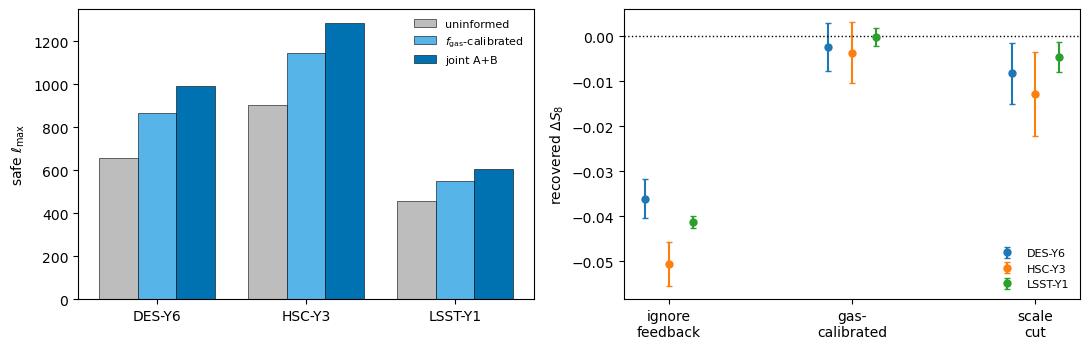

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.6))
sv_names = list(T["two_point_clkk"])
x = np.arange(len(sv_names)); w = 0.26
for i, (key, lab, c) in enumerate([
        ("prior", "uninformed", "#bdbdbd"),
        ("fgas_post", r"$f_{\rm gas}$-calibrated", "#56B4E9"),
        ("joint_post", "joint A+B", "#0072B2")]):
    axL.bar(x + (i - 1) * w,
            [T["two_point_clkk"][s][key]["lmax_safe"] for s in sv_names],
            w, color=c, label=lab, edgecolor="k", lw=0.4)
axL.set_xticks(x); axL.set_xticklabels(sv_names)
axL.set_ylabel(r"safe $\ell_{\max}$"); axL.legend(frameon=False, fontsize=8)

for j, s in enumerate(sv_names):
    r = S["surveys"][s]
    ks = ["uncorrected", "calibrated", "scale_cut"]
    axR.errorbar(np.arange(3) + (j - 1) * 0.13,
                 [r[k]["delta_S8"] for k in ks],
                 yerr=[r[k]["sigma_S8"] for k in ks],
                 fmt="o", ms=5, capsize=2.5, label=s)
axR.axhline(0, color="k", ls=":", lw=1)
axR.set_xticks(range(3))
axR.set_xticklabels(["ignore\nfeedback", "gas-\ncalibrated", "scale\ncut"])
axR.set_ylabel(r"recovered $\Delta S_8$"); axR.legend(frameon=False, fontsize=8)
fig.tight_layout()

## 7. The systematic that gets asked about first

The calibration is performed at a **fixed** (TNG300) cosmology, so an
analyst applying it elsewhere in $(\Omega_m, \sigma_8)$ incurs an error.
We quantify it with the FLAMINGO cosmology-coupling result of Elbers et
al. (2024, arXiv:2403.12967), whose $\xi^2 = f_b/c_v^2$ scaling with
$\alpha = 13.8 \pm 0.6$ we apply as a band proportional to the local
suppression depth.

It is real but subdominant: ~0.3 of the calibrated band width, costing
under 1% in $\ell_{\max}$. Our fiducial $\xi^2$ lands mid-range of their
own fitted interval, which is a useful check that we are inside their
calibration rather than extrapolating it — values that fall outside are
flagged in the artifact.

In [9]:
E = load("wp7_cosmology/elbers_band.json")
print(f"fiducial: {E['fiducial']}")
print(f"\n{'cosmology':38s} {'dF_b/(1-F_b)':>13s}   note")
for name, d in E["points"].items():
    flag = "EXTRAPOLATED beyond their fit range" \
        if d["outside_elbers_fitted_range"] else ""
    print(f"{name:38s} {100*d['rel_suppression_change']:+12.2f}%   {flag}")

print("\nCost in safe scales (joint A+B band):")
for sv, p in E["safescale_propagation_at_DES_Y3_like"].items():
    q = p["joint_post"]
    print(f"  {sv:10s} {q['lmax_safe_no_elbers']:7.1f} -> "
          f"{q['lmax_safe_with_elbers']:7.1f}")

fiducial: {'Omega_m': 0.3089, 'sigma_8': 0.8159, 'Omega_b': 0.0486, 'f_b': 0.15733247005503398, 'c_v': 1.043766948010889, 'xi2': 0.14441465939059006}

cosmology                               dF_b/(1-F_b)   note
TNG300 fiducial (calibration point)           -0.00%   
Planck-like (0.315, 0.811)                    +4.52%   
DES-Y3-like (0.339, 0.733)                   +17.05%   EXTRAPOLATED beyond their fit range
KiDS-like (0.305, 0.760)                      -6.82%   
low-S8 corner of the box                     -84.59%   EXTRAPOLATED beyond their fit range
high-S8 corner of the box                    +58.51%   EXTRAPOLATED beyond their fit range

Cost in safe scales (joint A+B band):
  DES-Y6       992.2 ->   986.0
  HSC-Y3      1286.8 ->  1275.8
  LSST-Y1      605.1 ->   605.1


## 8. Caveats, stated rather than buried

1. **The posterior belongs to a rejected model.** Posterior predictive
   $p = 0.000$; every block is rejected at the MAP. The calibrated band is
   the range TNG feedback can be *calibrated to*, not a measurement of the
   Universe's feedback. Every $S_8$ number inherits this.
2. **The $S_8$ injection is at the band's strong edge**, not its centre —
   injecting at the median would drive the calibrated bias to zero by
   construction and would not be a test. These are the ~1$\sigma$-unlucky
   case.
3. **Higher-order statistics carry no shape noise.** The suite maps are
   noiseless, so shape-noise-induced peaks — which populate low $|\nu|$
   and dilute feedback sensitivity — are absent. The peak/minima safe
   fractions are therefore optimistic at low $|\nu|$.
4. **Peaks are safe per-bin and unsafe coherently.** Every individual
   $\nu$ bin passes the criterion while the coherent amplitude direction
   does not ($b/\sigma \approx 1.0$). Per-bin safety fractions are the
   misleading statistic; the coherent direction is what biases a
   parameter.
5. **Fixed cosmology** (§7), and the **halo-pasting ceiling**: the
   suppression capture is ~90%, so quoted corrections are that much
   incomplete. Envelopes are validated for $\ell \lesssim 8000$; raw
   emulator dimensions above $\ell \sim 10^4$ are noisy and must not enter
   safe-scale integrals.

## Reproducibility

Expensive stages — the CAMELS-TNG design runs, the lightcone maps, the
emulator training, the chains — ran on the Flatiron Institute clusters.
This notebook re-derives only cheap diagnostics and re-plots frozen
products. The `provenance` records in each artifact carry the job-level
detail.

External code: the shear$\times$tSZ comparison uses the GODMAX
implementation from its public repository — please cite the GODMAX papers
alongside this work.